# Hash tables and the CPU cache

Comparing two ways of handling collisions in a hash table:

- **open addressing** with linear probing (every entry lives in one big array)
- **separate chaining** (each bucket points to a linked list of nodes)

The question isn't "which does fewer operations" (they're similar on paper), but
"which is friendlier to the cache" on a real machine.

**A heads-up about doing this in pure Python.** Python is honestly a poor language
for *measuring* cache effects. A normal Python object lives somewhere random on the
heap, and the interpreter adds a fixed cost to every single operation. That fixed cost
(tens to hundreds of nanoseconds) is in the same ballpark as a cache miss (~100 ns), so
the timing numbers are noisier and smaller than what you'd see in C. That's exactly why
there are **two** experiments:

1. **Timing real tables.** Open addressing stores its keys in one contiguous array;
   chaining uses lots of little node objects scattered around the heap. The cache effect
   shows through, just muffled by interpreter overhead.
2. **A cache simulator.** We record the exact sequence of memory addresses each table
   would touch, then run that sequence through a tiny cache model that just counts hits
   and misses. No interpreter noise, so the real difference comes out clean.

Run the cells top to bottom. Charts render inline.

In [1]:
%matplotlib inline
import time
import random
import gc                         # we pause garbage collection during timed runs
from array import array          # contiguous primitive storage (no per-access object overhead)
import numpy as np
import matplotlib.pyplot as plt

# On every modern x86/ARM chip a cache line is 64 bytes, so touching one byte
# actually drags in 64 neighbouring bytes for free. That single fact is the
# reason contiguous data structures win.
LINE_BYTES = 64

# Fixed seeds so the results are reproducible.
random.seed(0)
np.random.seed(0)

## The two data structures

In [2]:
class LinearProbingTable:
    """Open addressing. All keys live in one contiguous array. On a collision
    we just walk forward to the next slot, which means we mostly stay inside
    the same cache line."""

    EMPTY = -1  # our keys are all >= 0, so -1 is a safe "nothing here" marker

    def __init__(self, capacity):
        self.capacity = capacity
        # array.array keeps these as raw 8-byte integers packed side by side in
        # one block of memory. Reading a slot does NOT chase a pointer to some
        # object on the heap, which is the whole reason this layout is cache
        # friendly. ('q' is a signed 64-bit int.)
        self.keys = array('q', [self.EMPTY]) * capacity
        self.values = array('q', [self.EMPTY]) * capacity

    def insert(self, key, value):
        # Capacity is a power of two, so "key % capacity" only looks at the low
        # bits. Our keys are random, so that's fine as a simple hash.
        i = key % self.capacity
        while self.keys[i] != self.EMPTY and self.keys[i] != key:
            i += 1
            if i == self.capacity:   # wrap around the end of the array
                i = 0
        self.keys[i] = key
        self.values[i] = value

    def lookup(self, key):
        i = key % self.capacity
        k = self.keys[i]               # read the slot once, reuse it below
        while k != self.EMPTY:
            if k == key:
                return self.values[i]
            i += 1
            if i == self.capacity:
                i = 0
            k = self.keys[i]
        return None

In [3]:
class Node:
    # One linked-list node. The important thing is that every Node is its own
    # object allocated whenever it's inserted, so two nodes that end up in the
    # same bucket are usually FAR apart in memory. That's what costs us misses.
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.next = None


class ChainingTable:
    """Separate chaining. The bucket array is contiguous, but following a chain
    means hopping between scattered Node objects (pointer chasing)."""

    def __init__(self, capacity):
        self.capacity = capacity
        self.buckets = [None] * capacity  # each entry is the head of a chain

    def insert(self, key, value):
        i = key % self.capacity
        node = self.buckets[i]
        while node is not None:
            if node.key == key:
                node.value = value
                return
            node = node.next
        # not found, so add a fresh node at the front of the chain
        new_node = Node(key, value)
        new_node.next = self.buckets[i]
        self.buckets[i] = new_node

    def lookup(self, key):
        node = self.buckets[key % self.capacity]
        while node is not None:
            if node.key == key:
                return node.value
            node = node.next
        return None

## Experiment 1: time real lookups

As the table grows it stops fitting in L1, then L2, then L3. We want to watch chaining
fall behind once the data spills out of the small caches. We also sweep the load factor,
where open addressing is expected to suffer from clustering.

In [4]:
def make_keys(n):
    # n random keys. The range is enormous compared to n, so accidental
    # duplicates basically never happen and we don't bother filtering them.
    return np.random.randint(0, 2**60, size=n, dtype=np.int64)


def time_lookups(table, lookup_keys, repeats=5):
    # Time the whole batch a few times and keep the fastest run. The fastest run
    # is the one that got the cleanest shot at the CPU, so taking the minimum
    # throws away one-off slowdowns (the OS scheduling something else, etc).
    # We also switch off Python's garbage collector while timing, otherwise a GC
    # pause can land in the middle of a run and show up as a fake spike.
    best = None
    gc.disable()
    try:
        for _ in range(repeats):
            start = time.perf_counter()
            for k in lookup_keys:
                table.lookup(k)
            elapsed = time.perf_counter() - start
            if best is None or elapsed < best:
                best = elapsed
    finally:
        gc.enable()
    return best / len(lookup_keys) * 1e9  # nanoseconds per lookup


def build_tables(capacity, load_factor):
    # Build one open-addressing table and one chaining table holding the same
    # random keys, filled to the requested load factor. Returns the keys too so
    # the caller can look up things that are actually present.
    n = int(capacity * load_factor)
    keys = make_keys(n)
    oa = LinearProbingTable(capacity)
    ch = ChainingTable(capacity)
    for k in keys:
        k = int(k)
        oa.insert(k, k)
        ch.insert(k, k)
    return oa, ch, keys


def warm_up():
    # On a shared cloud VM (like Colab) the CPU starts slow and ramps up to full
    # speed over the first second or so. Do a bit of throwaway work first so that
    # ramp-up doesn't get blamed on whatever we measure first.
    oa, ch, keys = build_tables(2**18, 0.7)
    probe = [int(k) for k in keys[:5000]]
    time_lookups(oa, probe)
    time_lookups(ch, probe)

### 1a. Lookup time vs table size (load factor 0.7)

Small tables fit in cache, so the lighter per-operation cost wins. Once the table outgrows
the cache, the locality of open addressing should let it overtake chaining.

cap=2^12  OA key array=      32 KB   open addr= 491.4 ns   chaining= 188.4 ns   (chaining 0.38x slower)
cap=2^14  OA key array=     128 KB   open addr= 498.1 ns   chaining= 229.6 ns   (chaining 0.46x slower)
cap=2^16  OA key array=     512 KB   open addr= 572.7 ns   chaining= 444.0 ns   (chaining 0.78x slower)
cap=2^18  OA key array=    2048 KB   open addr= 648.5 ns   chaining= 567.6 ns   (chaining 0.88x slower)
cap=2^20  OA key array=    8192 KB   open addr= 705.4 ns   chaining= 655.2 ns   (chaining 0.93x slower)
cap=2^21  OA key array=   16384 KB   open addr= 705.0 ns   chaining= 665.1 ns   (chaining 0.94x slower)
cap=2^22  OA key array=   32768 KB   open addr= 726.9 ns   chaining= 762.0 ns   (chaining 1.05x slower)
cap=2^23  OA key array=   65536 KB   open addr= 767.4 ns   chaining= 855.0 ns   (chaining 1.11x slower)


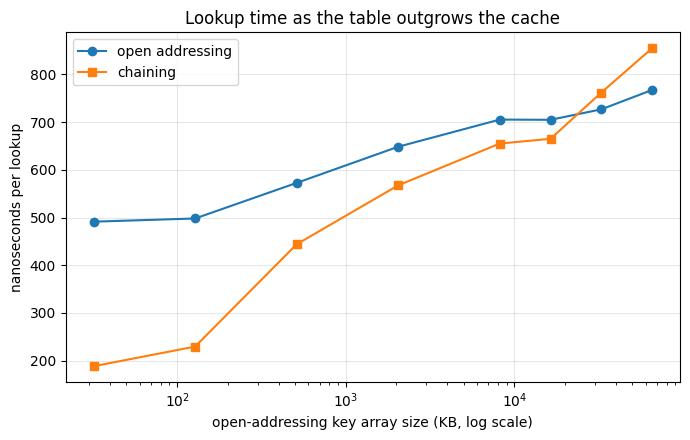

In [5]:
capacities = [2**12, 2**14, 2**16, 2**18, 2**20, 2**21, 2**22, 2**23]
load_factor = 0.7
num_lookups = 80_000
passes = 3   # measure the whole sweep this many times and keep the best per size

# Colab is a shared machine, so any single timing can land while the VM is
# throttled. Measuring the sweep in spread-out passes and keeping the minimum
# per size means a brief slowdown can't ruin every pass of the same size.
warm_up()
oa_times = [float("inf")] * len(capacities)
ch_times = [float("inf")] * len(capacities)

for _ in range(passes):
    for j, cap in enumerate(capacities):
        oa, ch, keys = build_tables(cap, load_factor)
        picks = np.random.randint(0, len(keys), size=num_lookups)
        lookup_list = [int(keys[i]) for i in picks]
        oa_times[j] = min(oa_times[j], time_lookups(oa, lookup_list))
        ch_times[j] = min(ch_times[j], time_lookups(ch, lookup_list))

for j, cap in enumerate(capacities):
    print(f"cap=2^{int(np.log2(cap)):<2}  OA key array={cap * 8 / 1024:8.0f} KB"
          f"   open addr={oa_times[j]:6.1f} ns   chaining={ch_times[j]:6.1f} ns"
          f"   (chaining {ch_times[j] / oa_times[j]:.2f}x slower)")

plt.figure(figsize=(7, 4.5))
plt.plot([c * 8 / 1024 for c in capacities], oa_times, "o-", label="open addressing")
plt.plot([c * 8 / 1024 for c in capacities], ch_times, "s-", label="chaining")
plt.xscale("log")
plt.xlabel("open-addressing key array size (KB, log scale)")
plt.ylabel("nanoseconds per lookup")
plt.title("Lookup time as the table outgrows the cache")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1b. Lookup time vs load factor (capacity 2^20)

Fix a biggish table and crank the load factor up. Open addressing should start to suffer
as it fills (long probe runs), giving back some of its advantage, while chaining stays
roughly flat.

load=0.50   open addr= 556.5 ns   chaining= 606.5 ns
load=0.60   open addr= 598.4 ns   chaining= 636.5 ns
load=0.70   open addr= 688.8 ns   chaining= 660.2 ns
load=0.80   open addr= 835.4 ns   chaining= 684.7 ns
load=0.90   open addr=1240.7 ns   chaining= 707.1 ns
load=0.95   open addr=2014.3 ns   chaining= 709.3 ns


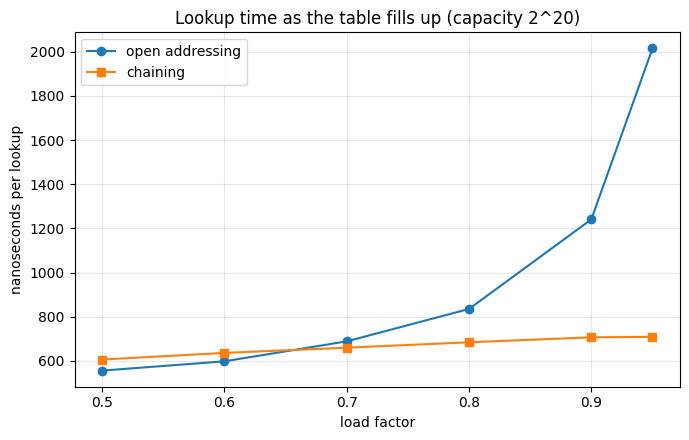

In [7]:
cap = 2**20
load_factors = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
num_lookups = 80_000
passes = 3

warm_up()
oa_lf = [float("inf")] * len(load_factors)
ch_lf = [float("inf")] * len(load_factors)

for _ in range(passes):
    for j, lf in enumerate(load_factors):
        oa, ch, keys = build_tables(cap, lf)
        picks = np.random.randint(0, len(keys), size=num_lookups)
        lookup_list = [int(keys[i]) for i in picks]
        oa_lf[j] = min(oa_lf[j], time_lookups(oa, lookup_list))
        ch_lf[j] = min(ch_lf[j], time_lookups(ch, lookup_list))

for j, lf in enumerate(load_factors):
    print(f"load={lf:.2f}   open addr={oa_lf[j]:6.1f} ns   chaining={ch_lf[j]:6.1f} ns")

plt.figure(figsize=(7, 4.5))
plt.plot(load_factors, oa_lf, "o-", label="open addressing")
plt.plot(load_factors, ch_lf, "s-", label="chaining")
plt.xlabel("load factor")
plt.ylabel("nanoseconds per lookup")
plt.title("Lookup time as the table fills up (capacity 2^20)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Experiment 2: a tiny cache simulator

Wall-clock time in Python is mostly interpreter overhead, so here we measure the thing we
actually care about directly: cache misses. We record the sequence of memory addresses each
table touches during lookups and feed it through a small set-associative cache model that
only counts hits and misses.

In [8]:
class Cache:
    """A set-associative cache with LRU replacement. We don't store any real
    data, only which cache lines are currently 'in' the cache, because all we
    want out of this is the hit/miss count."""

    def __init__(self, size_bytes, ways=8, line_bytes=LINE_BYTES):
        self.line_bytes = line_bytes
        self.ways = ways
        num_lines = size_bytes // line_bytes
        self.num_sets = max(1, num_lines // ways)
        # Each set holds up to `ways` line ids, ordered most-recent first.
        self.sets = [[] for _ in range(self.num_sets)]
        self.hits = 0
        self.misses = 0

    def access(self, address):
        line = address // self.line_bytes      # which 64-byte line is this?
        s = line % self.num_sets               # which set does it map to?
        bucket = self.sets[s]
        if line in bucket:
            self.hits += 1
            bucket.remove(line)                # move it to the front (just used)
            bucket.insert(0, line)
        else:
            self.misses += 1
            bucket.insert(0, line)
            if len(bucket) > self.ways:
                bucket.pop()                   # kick out the least recently used

    def miss_rate(self):
        total = self.hits + self.misses
        return self.misses / total if total else 0.0

In [9]:
# We pretend each structure lives in its own far-away region of memory so they
# never accidentally share cache lines in the simulation.
OA_BASE = 0
BUCKET_BASE = 1 << 40
NODE_BASE = 1 << 50

SLOT_BYTES = 8    # one 8-byte key per open-addressing slot
PTR_BYTES = 8     # one 8-byte head pointer per bucket
NODE_BYTES = 32   # a compact C-style node: key + value + next pointer


def build_open_addressing_slots(capacity, keys):
    # Replay the inserts so we know which key ends up in which slot.
    table = [-1] * capacity
    for k in keys:
        i = k % capacity
        while table[i] != -1 and table[i] != k:
            i = (i + 1) % capacity
        table[i] = k
    return table


def open_addressing_trace(table, capacity, lookup_keys):
    # Yield every memory address a lookup would read while probing.
    for k in lookup_keys:
        i = k % capacity
        while True:
            yield OA_BASE + i * SLOT_BYTES
            if table[i] == k or table[i] == -1:
                break
            i = (i + 1) % capacity


def build_chaining_nodes(capacity, keys):
    # Build the chains, and hand each node a pretend memory address using a
    # bump allocator: addresses go up by NODE_BYTES in *insertion* order.
    # Since we insert in random key order, nodes that share a bucket are
    # scattered all over that address range -- which is the whole point.
    heads = [None] * capacity
    addr, key, nxt = [], [], []
    free = NODE_BASE
    for k in keys:
        nid = len(addr)
        addr.append(free)
        free += NODE_BYTES
        key.append(k)
        nxt.append(heads[k % capacity])   # prepend to the chain
        heads[k % capacity] = nid
    return heads, addr, key, nxt


def chaining_trace(heads, addr, key, nxt, capacity, lookup_keys):
    for k in lookup_keys:
        i = k % capacity
        yield BUCKET_BASE + i * PTR_BYTES   # read the bucket's head pointer
        nid = heads[i]
        while nid is not None:
            yield addr[nid]                 # then jump to the node itself
            if key[nid] == k:
                break
            nid = nxt[nid]


def run_through_cache(trace, size_bytes, ways=8):
    cache = Cache(size_bytes, ways=ways)
    for address in trace:
        cache.access(address)
    return cache.miss_rate()

### 2a. Miss rate by cache level

One table, three cache sizes standing in for L1 / L2 / L3.

L1 (32 KB)    open addr miss= 48.6%   chaining miss= 97.9%
L2 (256 KB)   open addr miss= 25.5%   chaining miss= 83.8%
L3 (8 MB)     open addr miss= 11.8%   chaining miss= 36.8%


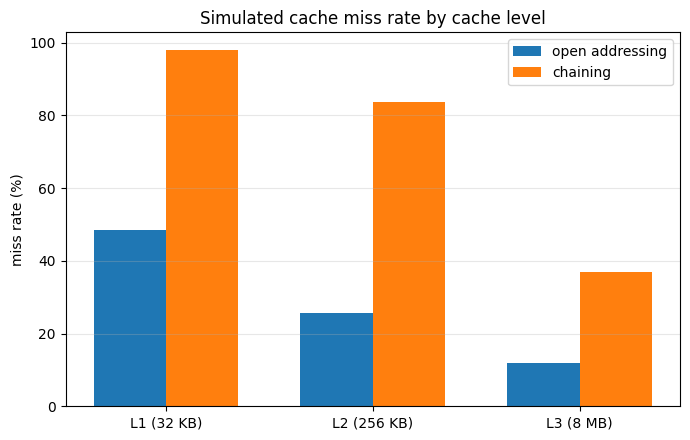

In [10]:
capacity = 2**16
load_factor = 0.7
n = int(capacity * load_factor)
keys = [int(x) for x in make_keys(n)]
lookups = [keys[i] for i in np.random.randint(0, n, size=30_000)]

table = build_open_addressing_slots(capacity, keys)
heads, addr, key, nxt = build_chaining_nodes(capacity, keys)

levels = [("L1 (32 KB)", 32 * 1024, 8),
          ("L2 (256 KB)", 256 * 1024, 8),
          ("L3 (8 MB)", 8 * 1024 * 1024, 16)]

labels, oa_lvl, ch_lvl = [], [], []
for name, size, ways in levels:
    oa = run_through_cache(open_addressing_trace(table, capacity, lookups), size, ways)
    ch = run_through_cache(chaining_trace(heads, addr, key, nxt, capacity, lookups), size, ways)
    labels.append(name)
    oa_lvl.append(oa * 100)
    ch_lvl.append(ch * 100)
    print(f"{name:12s}  open addr miss={oa * 100:5.1f}%   chaining miss={ch * 100:5.1f}%")

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(7, 4.5))
plt.bar(x - width / 2, oa_lvl, width, label="open addressing")
plt.bar(x + width / 2, ch_lvl, width, label="chaining")
plt.xticks(x, labels)
plt.ylabel("miss rate (%)")
plt.title("Simulated cache miss rate by cache level")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 2b. Miss rate vs table size (fixed L2-sized cache)

Fix the cache and grow the table. We want to see which scheme spills out of the cache first.

table key array=     32 KB   open addr miss=  1.2%   chaining miss=  4.1%
table key array=     64 KB   open addr miss=  2.4%   chaining miss=  8.3%
table key array=    128 KB   open addr miss=  4.6%   chaining miss= 43.2%
table key array=    256 KB   open addr miss=  9.0%   chaining miss= 69.1%
table key array=    512 KB   open addr miss= 27.1%   chaining miss= 84.3%
table key array=   1024 KB   open addr miss= 39.4%   chaining miss= 91.8%


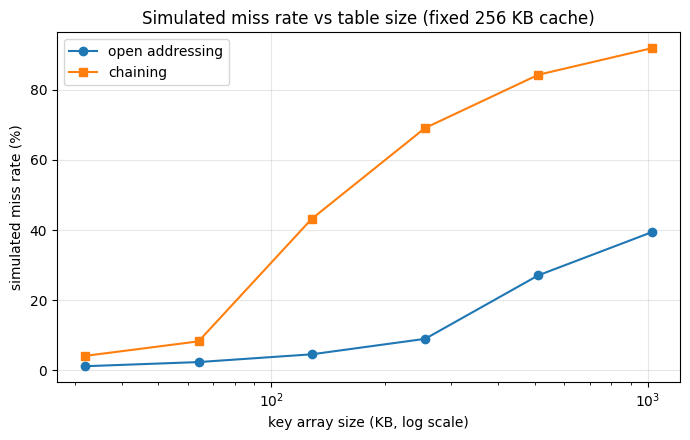

In [11]:
capacities = [2**12, 2**13, 2**14, 2**15, 2**16, 2**17]
load_factor = 0.7
cache_size = 256 * 1024

sizes_kb, oa_sz, ch_sz = [], [], []
for cap in capacities:
    n = int(cap * load_factor)
    keys = [int(x) for x in make_keys(n)]
    lookups = [keys[i] for i in np.random.randint(0, n, size=20_000)]

    table = build_open_addressing_slots(cap, keys)
    heads, addr, key, nxt = build_chaining_nodes(cap, keys)

    oa = run_through_cache(open_addressing_trace(table, cap, lookups), cache_size)
    ch = run_through_cache(chaining_trace(heads, addr, key, nxt, cap, lookups), cache_size)

    sizes_kb.append(cap * 8 / 1024)
    oa_sz.append(oa * 100)
    ch_sz.append(ch * 100)
    print(f"table key array={cap * 8 / 1024:7.0f} KB"
          f"   open addr miss={oa * 100:5.1f}%   chaining miss={ch * 100:5.1f}%")

plt.figure(figsize=(7, 4.5))
plt.plot(sizes_kb, oa_sz, "o-", label="open addressing")
plt.plot(sizes_kb, ch_sz, "s-", label="chaining")
plt.xscale("log")
plt.xlabel("key array size (KB, log scale)")
plt.ylabel("simulated miss rate (%)")
plt.title("Simulated miss rate vs table size (fixed 256 KB cache)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## What to look for

- **1a** should show a *crossover*: chaining is quicker while everything fits in cache, then
  open addressing overtakes it once the table grows past the last-level cache.
- **1b** should show open addressing climbing at high load factors (clustering) while chaining
  stays flat.
- **2a / 2b** are the clean results: chaining misses far more at every cache level and spills
  out of a fixed cache much earlier.

Absolute nanosecond values depend on the machine, so your Colab numbers will differ from any
reference run, but the shapes of the curves should hold. The size sweep runs out to `2**23`
(a 64 MB key array), past most last-level caches, so the open-addressing/chaining crossover
should be visible. Timing disables the garbage collector and measures the whole sweep in three
spread-out passes, keeping the best time per size, which suppresses the spikes you get on a
shared VM. That makes Experiment 1 the slow part (~4-5 minutes); the simulator is quick.